# Change Point Analysis and Statistical Modeling of Time Series Data

### Complete Steps
1. Exploratory Data Analysis (EDA) - Data Acquisition & Preprocessing
2. Diagnostic Profiling
3. Event Layering
2. Defining a Bayesian change point model in PyMC
3. Running the MCMC sampler (NUTS)
4. Convergence diagnostics (R-hat, trace plots, ESS)
5. Interpreting posterior distributions & quantifying impact

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from statsmodels.tsa.stattools import adfuller

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.data_preprocessing import handleNullvalues
from src.time_series_analyzer import compute_log_returns, execute_adf_test, TimeSeriesDataError

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Exploratory Data Analysis

In [2]:
df = pd.read_csv('../data/raw/BrentOilPrices.csv')
df.head(3)

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55


In [3]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   object 
 1   Price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB


In [5]:
df.dtypes

Date      object
Price    float64
dtype: object

In [6]:
print(f"Data Timeframe: {df['Date'].min()} to {df['Date'].max()}")


Data Timeframe: 01-Apr-02 to Sep 30, 2022


In [3]:
df['Date'] = pd.to_datetime(df['Date'], format= 'mixed')
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')

In [8]:
df.dtypes

Date      object
Price    float64
dtype: object

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date     datetime64[ns]
Price           float64
dtype: object

In [5]:
print(f"Data Timeframe: {df['Date'].min()} to {df['Date'].max()}")


Data Timeframe: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


## Event Dataset EDA

In [30]:
df_ev = pd.read_csv('../data/raw/event_dataset.csv')
df_ev.head(3)

,Event ID,Event Start Date,Event Name,Shock Classification,Market Impact & Price Trajectory
0,EV-001,1990-08-02,Iraqi Invasion of Kuwait,Geopolitical / War,Triggered the First Gulf War Oil Shock. Crude ...
1,EV-002,1997-10-24,Asian Financial Crisis,Economic Recession,A collapse in Asian manufacturing and currency...
2,EV-003,2001-09-11,9/11 Terrorist Attacks,Geopolitical Shock,Prompted an immediate near-term collapse in gl...


In [32]:
df_ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Event ID                          15 non-null     object
 1   Event Start Date                  15 non-null     object
 2   Event Name                        15 non-null     object
 3   Shock Classification              15 non-null     object
 4   Market Impact & Price Trajectory  15 non-null     object
dtypes: object(5)
memory usage: 732.0+ bytes


In [33]:
df_ev.describe()

,Event ID,Event Start Date,Event Name,Shock Classification,Market Impact & Price Trajectory
count,15,15,15,15,15
unique,15,15,15,12,15
top,EV-001,1990-08-02,Iraqi Invasion of Kuwait,Geopolitical / War,Triggered the First Gulf War Oil Shock. Crude ...
freq,1,1,1,3,1


In [34]:
df_ev.dtypes

Event ID                            object
Event Start Date                    object
Event Name                          object
Shock Classification                object
Market Impact & Price Trajectory    object
dtype: object

In [36]:
df_ev['Event Start Date'] = pd.to_datetime(df_ev['Event Start Date'])
df_ev.dtypes

Event ID                                    object
Event Start Date                    datetime64[ns]
Event Name                                  object
Shock Classification                        object
Market Impact & Price Trajectory            object
dtype: object

## Plot Raw Price Series

In [5]:
N = 250                    # Number of days
TRUE_TAU = 120             # True change point (hidden)
TRUE_MU1 = 60.0            # Mean price BEFORE the change
TRUE_MU2 = 85.0            # Mean price AFTER the change
TRUE_SIGMA = 5.0           # Observation noise

# Generate price data
prices = np.concatenate([
    rng.normal(TRUE_MU1, TRUE_SIGMA, TRUE_TAU),
    rng.normal(TRUE_MU2, TRUE_SIGMA, N - TRUE_TAU)
])

# Create a DataFrame
dates = df['Date']
df.set_index("Date", inplace=True)

print(f"Total days       : {N}")
print(f"True switch point: day {TRUE_TAU} ({dates[TRUE_TAU].strftime('%Y-%m-%d')})")
print(f"True mu_before   : ${TRUE_MU1:.2f}")
print(f"True mu_after    : ${TRUE_MU2:.2f}")
print(f"True sigma       : ${TRUE_SIGMA:.2f}")
df.head()

Total days       : 250
True switch point: day 120 (1987-11-05)
True mu_before   : $60.00
True mu_after    : $85.00
True sigma       : $5.00


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


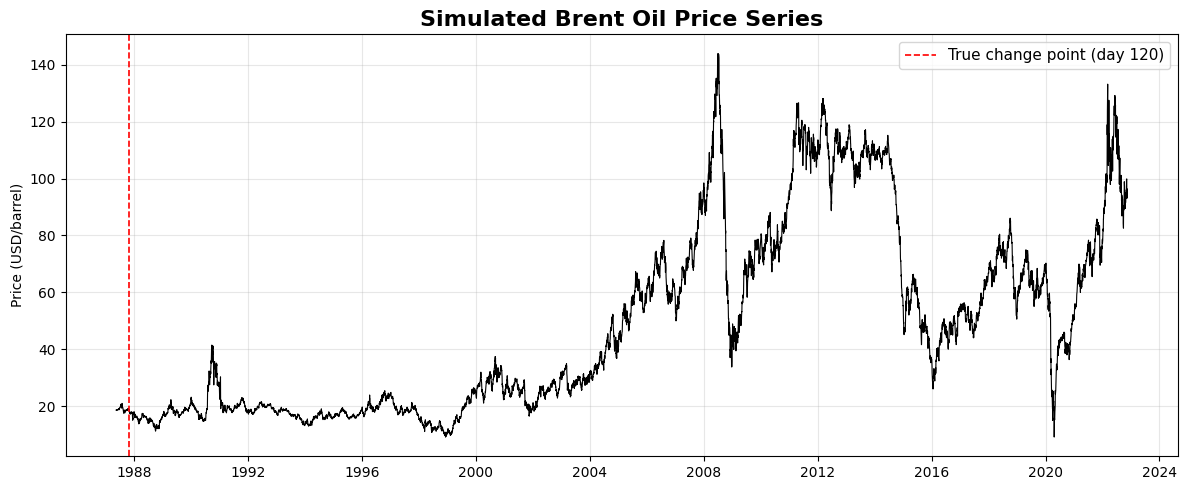

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["Price"], color="black", linewidth=0.8)
ax.axvline(dates[TRUE_TAU], color="red", linestyle="--", linewidth=1.2,
           label=f"True change point (day {TRUE_TAU})")
ax.set_title("Simulated Brent Oil Price Series", fontsize=16, fontweight="bold")
ax.set_ylabel("Price (USD/barrel)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Compute and plot log returns

2026-07-11 19:56:49,181 - INFO - Successfully computed log returns. Total active records: 9010


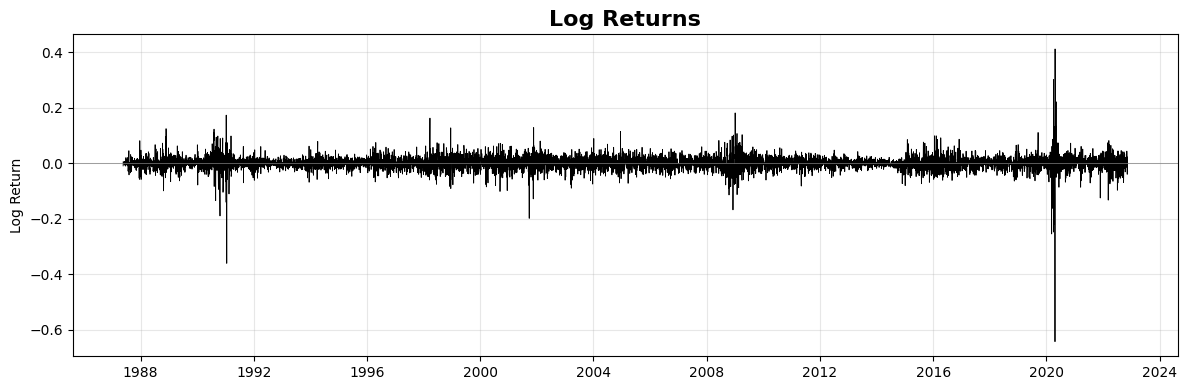

In [7]:
try:
    df["LogReturn"] = compute_log_returns(df, price_col="Price")
except Exception as global_err:
    print(f"An unexpected error occurred : {global_err}")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["LogReturn"], color="black", linewidth=0.6)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("Log Returns", fontsize=16, fontweight="bold")
ax.set_ylabel("Log Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### TIME-SERIES STATIONARITY

In [8]:
price_test = execute_adf_test(df["Price"], "Raw Prices")
price_test

2026-07-11 19:56:56,294 - INFO - Initiating ADF test routine for: Raw Prices
2026-07-11 19:56:56,729 - INFO - ADF execution completed for Raw Prices. Stationary status: False


Result: Fail to Reject Null Hypothesis. The Raw Prices series is NON-STATIONARY. (Do not model raw!)



{'series_name': 'Raw Prices',
 'adf_statistic': -1.9938560113924675,
 'p_value': 0.28927350489340287,
 'critical_values': {'1%': -3.4310783342658615,
  '5%': -2.861861876398633,
  '10%': -2.566941329781918},
 'is_stationary': False}

In [9]:
# to remove the very first row of the data as it has no previous data to perform log, it became Null
clean_log_returns = df["LogReturn"].replace([np.inf, -np.inf], np.nan).dropna()


In [10]:
returns_test = execute_adf_test(clean_log_returns, "Log Returns")
returns_test

2026-07-11 19:57:09,962 - INFO - Initiating ADF test routine for: Log Returns
2026-07-11 19:57:10,327 - INFO - ADF execution completed for Log Returns. Stationary status: True


Result: Reject Null Hypothesis. The Log Returns series is STATIONARY. (Safe to model)



{'series_name': 'Log Returns',
 'adf_statistic': -16.427113494485894,
 'p_value': 2.4985801611428892e-29,
 'critical_values': {'1%': -3.4310783342658615,
  '5%': -2.861861876398633,
  '10%': -2.566941329781918},
 'is_stationary': True}

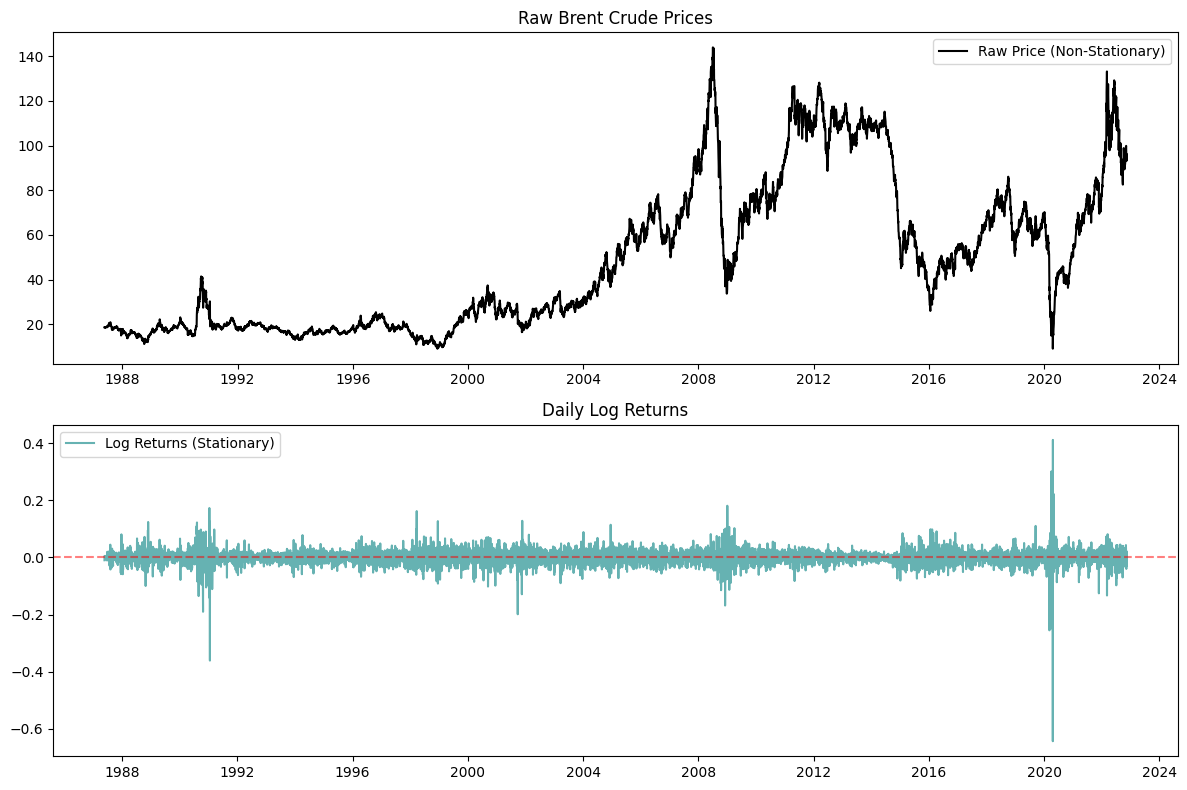

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# 1. Plot Raw Prices
ax[0].plot(df.index, df["Price"], color="black", label="Raw Price (Non-Stationary)")
ax[0].set_title("Raw Brent Crude Prices")
ax[0].legend()


ax[1].plot(clean_log_returns.index, clean_log_returns, color="teal", alpha=0.6, label="Log Returns (Stationary)")
ax[1].axhline(0, color="red", linestyle="--", alpha=0.5)
ax[1].set_title("Daily Log Returns")
ax[1].legend()

plt.tight_layout()
plt.show()

## Step 3: Define the Bayesian Change Point Model

**Model specification:**
- $\tau \sim \text{DiscreteUniform}(0, N)$ — the switch point
- $\mu_1 \sim \text{Normal}(\bar{y}, 10)$ — mean before tau
- $\mu_2 \sim \text{Normal}(\bar{y}, 10)$ — mean after tau
- $\sigma \sim \text{HalfNormal}(10)$ — observation noise
- $\mu_t$ is determined by 
- $y_t \sim \text{Normal}(\mu_t, \sigma)$ — likelihood

In [14]:
y = df["Price"].values
n_obs = len(y)
idx = np.arange(n_obs)
y_mean = y.mean()

print(f"Observations (n): {n_obs}")
print(f"Data mean       : ${y_mean:.2f}")

with pm.Model() as change_point_model:
    # --- Priors ---
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_obs - 1)
    mu1 = pm.Normal("mu1", mu=y_mean, sigma=10)
    mu2 = pm.Normal("mu2", mu=y_mean, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # --- Switch function ---
    mu = pm.math.switch(tau >= idx, mu1, mu2)

    # --- Likelihood ---
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

print("Model defined successfully.")

Observations (n): 9011
Data mean       : $48.42
Model defined successfully.


## Step 4: Run the MCMC Sampler
This may take a few minutes depending on your hardware.

In [ ]:
with change_point_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        cores=1,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )
print("Sampling complete.")

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


## Step 5: Convergence Diagnostics
### 5a. Summary table with R-hat and ESS

In [ ]:
summary = az.summary(trace, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary)

rhat_ok = (summary["r_hat"] < 1.05).all()
print(f"\nAll R-hat < 1.05? {'YES — chains converged' if rhat_ok else 'NO — investigate further'}")

### 5b. Trace plots

In [ ]:
az.plot_trace(trace, var_names=["tau", "mu1", "mu2", "sigma"], figsize=(14, 10))
plt.tight_layout()
plt.show()

## Step 6: Interpret the Posterior & Quantify Impact
### 6a. Posterior distributions of tau, mu1, mu2

In [ ]:
posterior = trace.posterior
tau_samples = posterior["tau"].values.flatten()
mu1_samples = posterior["mu1"].values.flatten()
mu2_samples = posterior["mu2"].values.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(tau_samples, bins=50, color="black", alpha=0.85, edgecolor="white")
axes[0].axvline(TRUE_TAU, color="red", linestyle="--", linewidth=2, label=f"True tau = {TRUE_TAU}")
axes[0].set_title("Posterior of tau (Change Point)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Day index")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(mu1_samples, bins=50, color="black", alpha=0.7, edgecolor="white")
axes[1].axvline(TRUE_MU1, color="red", linestyle="--", linewidth=2, label=f"True mu1 = {TRUE_MU1}")
axes[1].set_title("Posterior of mu1 (Before)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Price (USD)")
axes[1].legend()

axes[2].hist(mu2_samples, bins=50, color="black", alpha=0.7, edgecolor="white")
axes[2].axvline(TRUE_MU2, color="red", linestyle="--", linewidth=2, label=f"True mu2 = {TRUE_MU2}")
axes[2].set_title("Posterior of mu2 (After)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Price (USD)")
axes[2].legend()

plt.tight_layout()
plt.show()

### 6b. Quantify the impact

In [ ]:
tau_median = int(np.median(tau_samples))
mu1_median = np.median(mu1_samples)
mu2_median = np.median(mu2_samples)
pct_change = (mu2_median - mu1_median) / mu1_median * 100

tau_hdi = az.hdi(trace, var_names=["tau"], hdi_prob=0.94)
tau_low = int(tau_hdi["tau"].values[0])
tau_high = int(tau_hdi["tau"].values[1])

estimated_date = df.index[min(tau_median, len(df.index) - 1)]

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Estimated change point (median tau): day {tau_median}")
print(f"94% HDI for tau                    : [{tau_low}, {tau_high}]")
print(f"True change point                  : day {TRUE_TAU}")
print(f"Estimated mu_before                : ${mu1_median:.2f}")
print(f"Estimated mu_after                 : ${mu2_median:.2f}")
print(f"Price shift                        : {pct_change:+.1f}%")
print(f"\nInsight: The model detects a structural change point around")
print(f"{estimated_date.strftime('%Y-%m-%d')}, with the average daily price")
print(f"shifting from ${mu1_median:.2f} to ${mu2_median:.2f}, an increase of {pct_change:.1f}%.")

### 6c. Overlay estimated change point on price series

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["Price"], color="black", linewidth=0.8, label="Price")

ax.axvspan(df.index[0], df.index[min(tau_median, len(df.index) - 1)],
           alpha=0.08, color="black", label=f"Before (mu1 = ${mu1_median:.1f})")
ax.axvspan(df.index[min(tau_median, len(df.index) - 1)], df.index[-1],
           alpha=0.18, color="black", label=f"After (mu2 = ${mu2_median:.1f})")
ax.axvline(estimated_date, color="red", linestyle="--", linewidth=2,
           label=f"Estimated tau = {estimated_date.strftime('%Y-%m-%d')}")
ax.set_title("Estimated Change Point on Simulated Price Series",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Price (USD/barrel)")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()